© 2025 Mobile Perception Systems Lab at TU/e. All rights reserved. Licensed under the MIT License.

## Setup

In [21]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
cd /content/drive/MyDrive/AnomalySegmentation_Project

/content/drive/.shortcut-targets-by-id/1x2LBwdmPjKFuYwX3GTOrlr8KeH9a9SXK/AnomalySegmentation_Project


In [23]:
!pip install -r requirements.txt

In [24]:
cd /content/drive/MyDrive/AnomalySegmentation_Project/eomt

/content/drive/.shortcut-targets-by-id/1x2LBwdmPjKFuYwX3GTOrlr8KeH9a9SXK/AnomalySegmentation_Project/eomt


In [25]:
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
import warnings
import importlib

seed_everything(0, verbose=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_idx = 355 # TODO: change to the index of the image you want to visualize
config_path_coco = "configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"
config_path_cityscapes = "configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
data_path = "../Cityscapes"  # TODO: change to the dataset directory

with open(config_path_coco, "r") as f:
    config_coco = yaml.safe_load(f)

with open(config_path_cityscapes, "r") as f:
    config_city = yaml.safe_load(f)

def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

## Load dataset

Ensure the dataset files are correctly prepared and placed in the folder specified by `data_path`.

In [ ]:
#CITYSCAPES
data_module_name_city, class_name_city = config_city["data"]["class_path"].rsplit(".", 1)
data_module_city = getattr(importlib.import_module(data_module_name_city), class_name_city)
data_kwargs_city = config_city["data"].get("init_args", {})

data_city = data_module_city(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_kwargs_city
)
data_city.setup()


#COCO
data_module_name_coco, class_name_coco = config_coco["data"]["class_path"].rsplit(".", 1)
data_module_coco = getattr(importlib.import_module(data_module_name_coco), class_name_coco)
data_kwargs_coco = config_coco["data"].get("init_args", {})

data_coco_meta = data_module_coco(
    path="",
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_kwargs_coco
)

## Load model

In [ ]:
warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

def build_and_load_model(config, data_meta, weights_path):
    # Load encoder
    encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
    encoder = encoder_cls(img_size=data_meta.img_size, **encoder_cfg.get("init_args", {}))

    # Load network
    network_cfg = config["model"]["init_args"]["network"]
    network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
    network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}

    network = network_cls(
        masked_attn_enabled=False,
        num_classes=data_meta.num_classes,
        encoder=encoder,
        **network_kwargs,
    )

    # Load Lightning module
    lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
    lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
    model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}

    if "stuff_classes" in config["data"].get("init_args", {}):
        model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

    name = config.get("trainer", {}).get("logger", {}).get("init_args", {}).get("name", "")
    is_dinov3 = "dinov3" in name

    if is_dinov3:
        model_kwargs["ckpt_path"] = weights_path
        model_kwargs["delta_weights"] = True

    model = (
        lit_cls(
            img_size=data_meta.img_size,
            num_classes=data_meta.num_classes,
            network=network,
            **model_kwargs,
        )
        .eval()
        .to(device)
    )

    if not is_dinov3:
        try:
            ckpt = torch.load(weights_path, map_location=device)
            if isinstance(ckpt, dict) and "state_dict" in ckpt:
                state_dict = ckpt["state_dict"]
            else:
                state_dict = ckpt
            model.load_state_dict(state_dict, strict=False)
            print(f"Weights successfully loaded from {weights_path}!")

        except Exception as e:
            print(f"Error loading weights from {weights_path}: {e}")

    return model

#COCO
state_dict_path_coco = "weights/eomt_coco.bin"
print("Initializing COCO Panoptic model...")
model_panoptic = build_and_load_model(config_coco, data_coco_meta, state_dict_path_coco)

#CITYSCAPES
state_dict_path_city = "weights/eomt_cityscapes.bin"
print("Initializing Cityscapes Semantic model...")
model_semantic = build_and_load_model(config_city, data_city, state_dict_path_city)

## Semantic inference (pixel-wise classification)

> This inference method also works when applied to a model trained for panoptic segmentation.

Semantic inference computes per-pixel class scores by combining mask and class predictions:

$$
\sum_i p_i(c) \cdot m_i[h, w]
$$

Here, $p_i(c)$ is the class probability for class $c$ (excluding "no object"), and $m_i[h, w]$ is the sigmoid-normalized mask value for query $i$ at pixel $(h, w)$. The final class is selected by taking the argmax over classes.  
  
*This inference method was originally introduced in MaskFormer.*

In [ ]:
IGNORE_INDEX = 255

def infer_semantic(model_sem, data_val, img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        crops, origins = model_sem.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model_sem(crops)

        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], data_val.img_size, mode="bilinear"
        )

        crop_logits = model_sem.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model_sem.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model_sem.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[
        0
    ].numpy()
    return pred_array, target_array


def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

img, target = data_city.val_dataloader().dataset[img_idx]
pred_array, target_array = infer_semantic(model_semantic, data_city, img, target)
plot_semantic_results(img, pred_array, target_array)

## Panoptic inference (segmentation with instance IDs)

> This inference method also works when applied to a model trained for instance segmentation.

Panoptic inference assigns each pixel $[h, w]$ to the query $i$ that maximizes the product of class and mask confidence:

$$
p_i(c_i) \cdot m_i[h, w]
$$

where $c_i = \arg\max_c \, p_i(c)$ is the most likely class for query $i$. A pixel is assigned to a query only if both the class confidence and mask confidence are high. Pixels assigned to the same query form a segment labeled with $c_i$. "Stuff" segments with the same class are merged; "thing" segments are kept distinct using the query index. Low-confidence and heavily occluded predictions are filtered out.  
  
*This inference method was originally introduced in MaskFormer.*

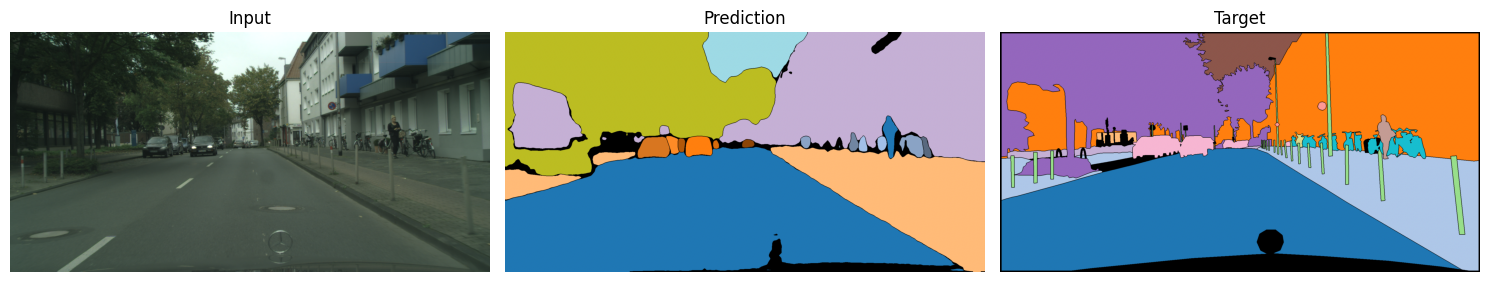

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import binary_dilation

def create_instance_aware_mapping(sem_array, inst_array, num_classes=19, ignore_index=255):
    mapping = {}
    unique_sem_ids = np.unique(sem_array)

    for sem_id in unique_sem_ids:
        if sem_id == -1 or sem_id == ignore_index or sem_id >= num_classes:
            inst_ids = np.unique(inst_array[sem_array == sem_id])
            for inst_id in inst_ids:
                mapping[(sem_id, inst_id)] = [0.0, 0.0, 0.0]
            continue

        base_rgb = plt.cm.tab20(sem_id % 20)[:3]
        base_hsv = mcolors.rgb_to_hsv(base_rgb)

        inst_ids_in_class = np.unique(inst_array[sem_array == sem_id])

        for i, inst_id in enumerate(inst_ids_in_class):
            hsv = base_hsv.copy()

            if len(inst_ids_in_class) > 1:
                hsv[2] = max(0.3, hsv[2] * (1.0 - 0.15 * (i % 4)))
                hsv[1] = max(0.3, hsv[1] * (1.0 - 0.1 * ((i // 4) % 3)))

            rgb_color = mcolors.hsv_to_rgb(hsv)
            mapping[(sem_id, inst_id)] = rgb_color

    return mapping

def apply_panoptic_colormap(sem_array, inst_array, mapping):
    colored_image = np.zeros((*sem_array.shape, 3))

    unique_sem_ids = np.unique(sem_array)
    for sem_id in unique_sem_ids:
        mask_sem = (sem_array == sem_id)
        unique_inst_ids = np.unique(inst_array[mask_sem])

        for inst_id in unique_inst_ids:
            mask_inst = mask_sem & (inst_array == inst_id)
            color = mapping.get((sem_id, inst_id), [0.0, 0.0, 0.0])
            colored_image[mask_inst] = color

    return colored_image

def draw_black_border(colored_image, inst_array, border_thickness=1):
    vis_img = colored_image.copy()
    unique_inst_ids = np.unique(inst_array)

    for inst_id in unique_inst_ids:
        mask_inst = (inst_array == inst_id)

        dilated_mask = binary_dilation(mask_inst, iterations=border_thickness)
        borders = dilated_mask & ~mask_inst

        vis_img[borders] = [0.0, 0.0, 0.0]

    return vis_img

def plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target, num_classes=19):
    mapping_pred = create_instance_aware_mapping(sem_pred, inst_pred, num_classes)
    mapping_target = create_instance_aware_mapping(sem_target, inst_target, num_classes)

    color_pred = apply_panoptic_colormap(sem_pred, inst_pred, mapping_pred)
    color_target = apply_panoptic_colormap(sem_target, inst_target, mapping_target)

    vis_pred = draw_black_border(color_pred, inst_pred)
    vis_target = draw_black_border(color_target, inst_target)

    img_np = (
        img.cpu().numpy().transpose(1, 2, 0) if img.dim() == 3 else img.cpu().numpy()
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Input")
    axes[1].imshow(vis_pred)
    axes[1].set_title("Prediction")
    axes[2].imshow(vis_target)
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data_city.val_dataloader().dataset[img_idx]
sem_pred, inst_pred, sem_target, inst_target = infer_panoptic(model_panoptic, img, target)

plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target, num_classes=model_panoptic.num_classes)